Feature Engineering (TF-IDF weighted Word2Vec & LDA Topic Modelling)

Since gensim runs on an incompatible version with numpy and pandas, hence the feature engineering of training Word2Vec and LDA topic modelling need to be carried out on virtual environment that is compatible for gensim to run

In [ ]:
# Import necessary library
import os
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import gensim
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

from gensim import corpora
from gensim.models import Word2Vec
from gensim.models.ldamodel import LdaModel
from gensim.corpora import Dictionary
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
from scipy.sparse import save_npz, load_npz, csr_matrix
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, LSTM

In [2]:
# Import previously splitted train and test dataset
train_data = pd.read_csv("train_data.csv")
test_data = pd.read_csv("test_data.csv")

print("Train and test data successfully reloaded.")

Train and test data successfully reloaded.


In [5]:
train_data

,Complaint_cleaned,Issue
0,"['law', 'office', 'nelson', 'win', 'judgment',...",threatened_negative_legal_action
1,"['not', 'duplicate', 'complaint', 'respond', '...",incorrect_info_credit_report
2,"['find', 'tax', 'lien', 'credit', 'report', 'f...",incorrect_info_credit_report
3,"['agency', 'year', 'ago', 'company', 'run', 'c...",attempt_collect_debt_not_owed
4,"['account', 'report', 'credit', 'report', 'ope...",incorrect_info_credit_report
...,...,...
46610,"['report', 'wrong', 'date', 'old', 'bankruptcy...",incorrect_info_credit_report
46611,"['paid', 'charge-of', 'account', 'state', 'liv...",incorrect_info_credit_report
46612,"['may', 'concern', 'charge', 'illegal', 'exces...",attempt_collect_debt_not_owed
46613,"['upon', 'review', 'credit', 'report', 'notice...",attempt_collect_debt_not_owed


In [11]:
test_data

,Complaint_cleaned,Issue
0,"['debt', 'name', 'appear', 'credit', 'report',...",attempt_collect_debt_not_owed
1,"['recently', 'purchase', 'mortgage', 'service'...",trouble_during_payment_process
2,"['receive', 'multiple', 'phone', 'call', 'some...",attempt_collect_debt_not_owed
3,"['home', 'instal', 'not', 'work', 'right', 'ke...",attempt_collect_debt_not_owed
4,"['receive', 'letter', 'frost', 'attempt', 'col...",attempt_collect_debt_not_owed
...,...,...
11649,"['may', 'concern', 'victim', 'identity', 'thef...",attempt_collect_debt_not_owed
11650,"['account', 'obtain', 'fraudulently', 'consume...",attempt_collect_debt_not_owed
11651,"['guy', 'claim', 'company', 'call', 'threatene...",threatened_negative_legal_action
11652,"['phone', 'message', 'call', 'back', 'phone', ...",attempt_collect_debt_not_owed


In [3]:
""" Check whether the complaint is a list of tokens or string 
as after reloading csv it could be changed into string """

# Check train_data
print(train_data['Complaint_cleaned'].head(3))
print(type(train_data['Complaint_cleaned'].iloc[0]))

print("")

# Check test_data
print(test_data['Complaint_cleaned'].head(3))
print(type(test_data['Complaint_cleaned'].iloc[0]))

0    ['law', 'office', 'nelson', 'win', 'judgment',...
1    ['not', 'duplicate', 'complaint', 'respond', '...
2    ['find', 'tax', 'lien', 'credit', 'report', 'f...
Name: Complaint_cleaned, dtype: object
<class 'str'>

0    ['debt', 'name', 'appear', 'credit', 'report',...
1    ['recently', 'purchase', 'mortgage', 'service'...
2    ['receive', 'multiple', 'phone', 'call', 'some...
Name: Complaint_cleaned, dtype: object
<class 'str'>


In [4]:
""" Convert the string back to list of tokens """
import ast

# Convert stringified lists back to real lists
train_data['Complaint_cleaned'] = train_data['Complaint_cleaned'].apply(ast.literal_eval)
test_data['Complaint_cleaned'] = test_data['Complaint_cleaned'].apply(ast.literal_eval)

In [5]:
""" Check after conversion """

# Check train_data
print(train_data['Complaint_cleaned'].head(3))
print(type(train_data['Complaint_cleaned'].iloc[0]))

print("")

# Check test_data
print(test_data['Complaint_cleaned'].head(3))
print(type(test_data['Complaint_cleaned'].iloc[0]))

0    [law, office, nelson, win, judgment, amount, t...
1    [not, duplicate, complaint, respond, back, reg...
2    [find, tax, lien, credit, report, file, state,...
Name: Complaint_cleaned, dtype: object
<class 'list'>

0    [debt, name, appear, credit, report, name, no,...
1    [recently, purchase, mortgage, service, right,...
2    [receive, multiple, phone, call, sometimes, pe...
Name: Complaint_cleaned, dtype: object
<class 'list'>


TF-IDF

In [ ]:
""" Compute TF-IDF on train data """
# Convert tokenized text back to sentences for TF-IDF
train_corpus = [" ".join(tokens) for tokens in train_data['Complaint_cleaned']]
test_corpus = [" ".join(tokens) for tokens in test_data['Complaint_cleaned']]

# Initialize TF-IDF vectorizer with unigram and bigram features
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2))

# Train TF-IDF on training data only (prevent data leakage)
tfidf_matrix_train = tfidf_vectorizer.fit_transform(train_corpus)

# Transform test data using the previously trained TF-IDF without relearning 
tfidf_matrix_test = tfidf_vectorizer.transform(test_corpus)

# Save TF-IDF vectorizer & matrices
with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf_vectorizer, f)

print("TF-IDF vectorizer trained and saved.")

TF-IDF vectorizer trained and saved.


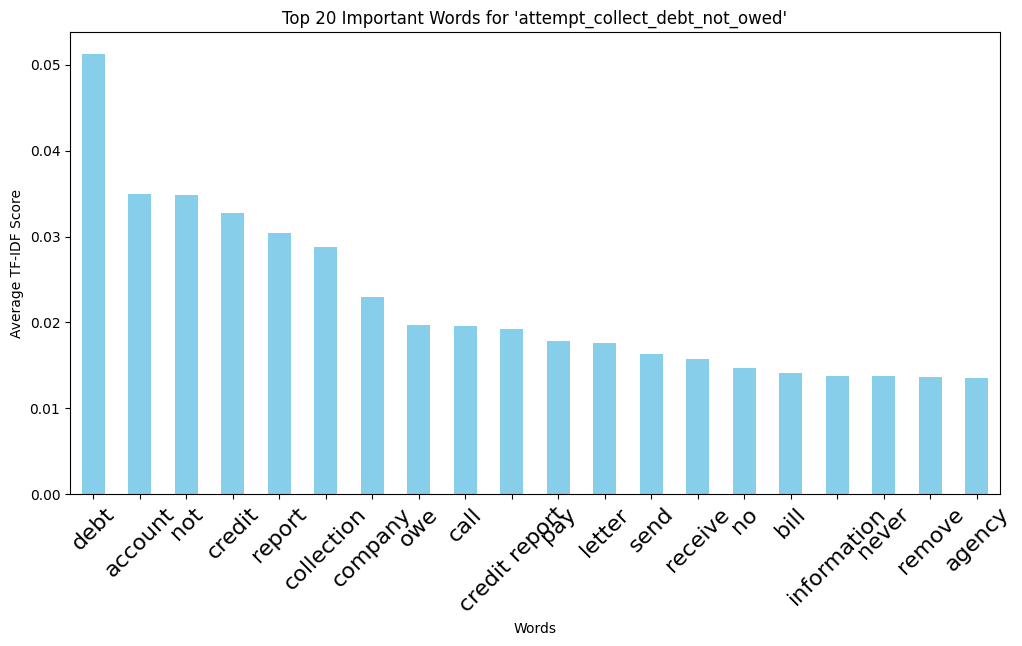

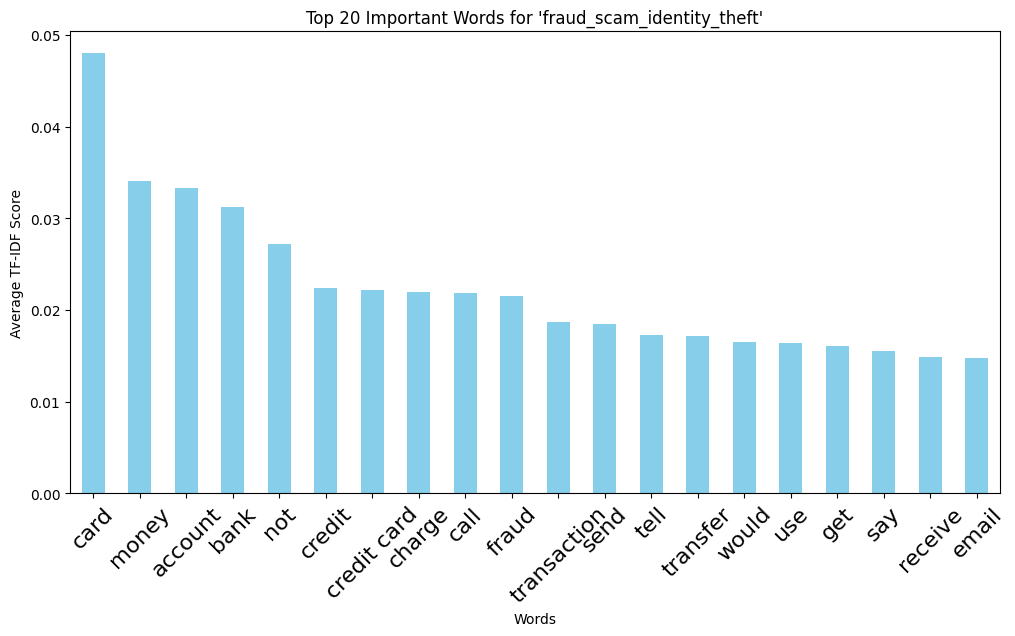

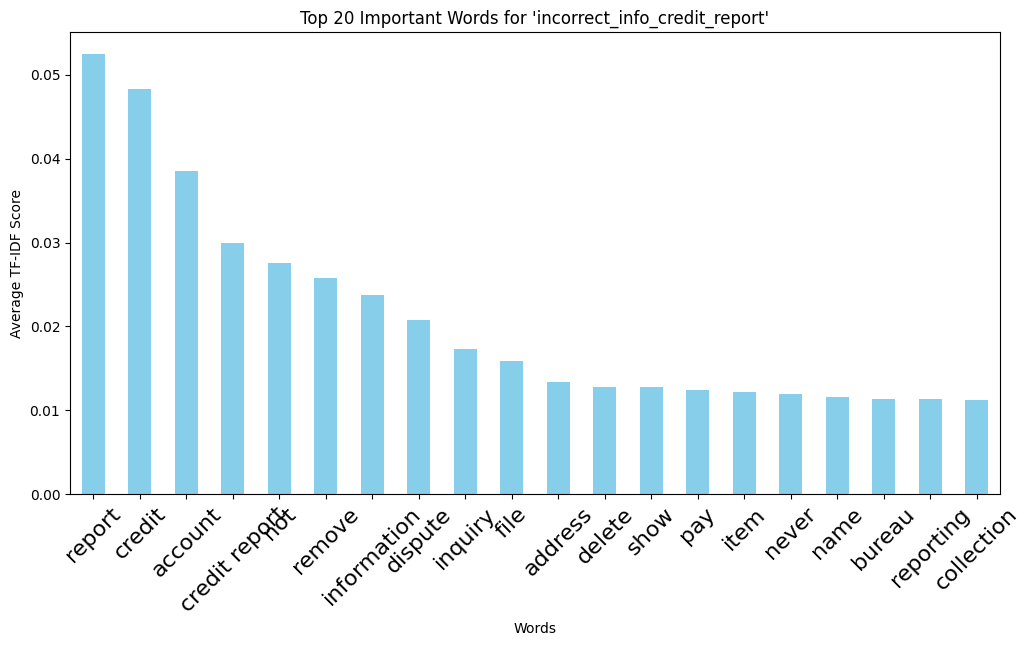

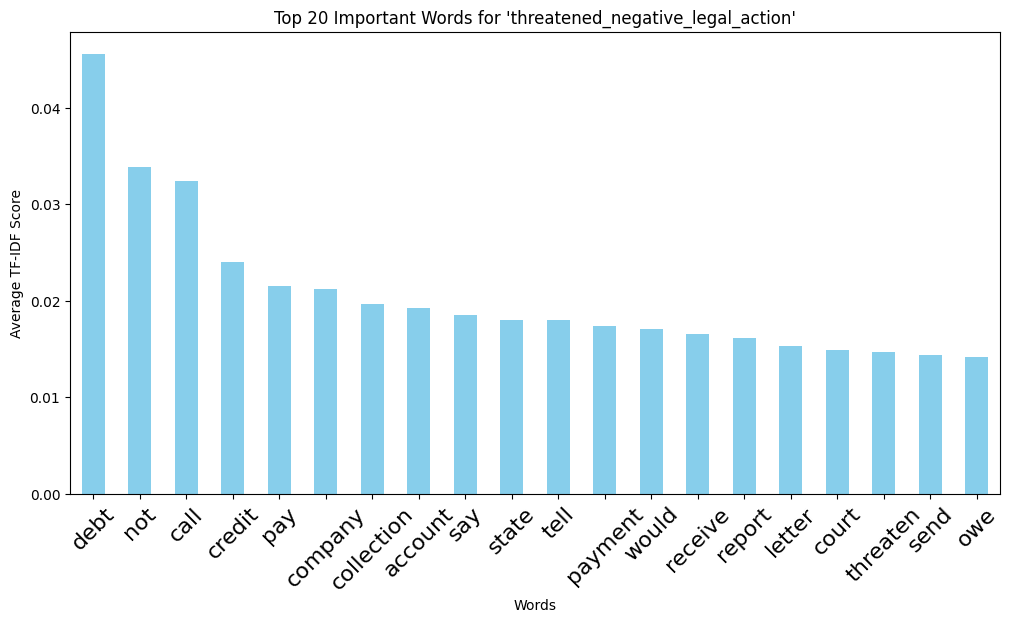

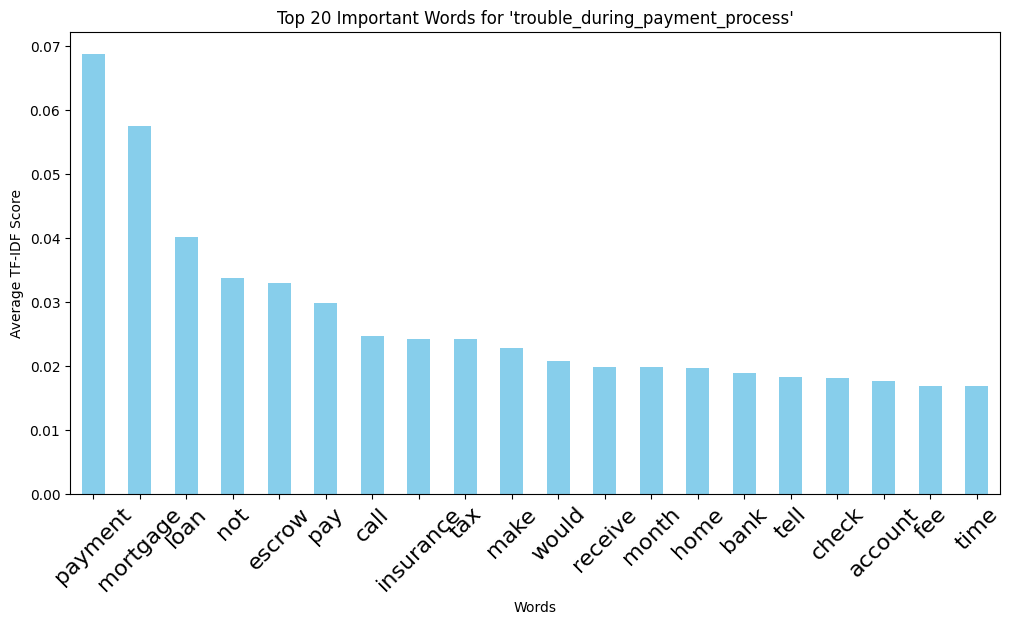

In [16]:
""" Word Importance Analysis of Each Issue Category """

# Extract feature names (words)
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

# Convert sparse matrix to DataFrame without converting to dense
tfidf_df = pd.DataFrame.sparse.from_spmatrix(tfidf_matrix_train, columns=feature_names)

# Add the "Issue" column from train data
tfidf_df["Issue"] = train_data["Issue"].values  # Ensure correct alignment

# Compute average TF-IDF per issue (sparse operation)
word_tfidf_by_issue = tfidf_df.groupby("Issue").mean()

# Plot top words for each issue
for issue in word_tfidf_by_issue.index:
    top_words = word_tfidf_by_issue.loc[issue].nlargest(20)  # Get top 20 words
    
    plt.figure(figsize=(12, 6))
    top_words.plot(kind="bar", color="skyblue")
    plt.title(f"Top 20 Important Words for '{issue}'")
    plt.xlabel("Words")
    plt.ylabel("Average TF-IDF Score")
    plt.xticks(rotation=45, fontsize = 16)
    plt.show()

Word2Vec

In [ ]:
""" Train Word2Vec Model """

# Train Word2Vec only on training data
w2v_model = Word2Vec(
    sentences=train_data['Complaint_cleaned'], 
    vector_size=100, 
    window=5, min_count=1, workers=4)

# Save the trained Word2Vec model
w2v_model.save("word2vec.model")

print("Word2Vec model trained and saved.")

Word2Vec model trained and saved.


TF-IDF Weighted Word2Vec

In [ ]:
""" Compute TF-IDF weighted Word2Vec """
# Create mapping: word -> index in TF-IDF feature space
feature_names = tfidf_vectorizer.get_feature_names_out()
feature_index = {word: idx for idx, word in enumerate(feature_names)}

def compute_tfidf_weighted_w2v(tokens, tfidf_vector, w2v_model):
    word_vecs = []
    weights = []
    # Convert sparse vector to dict: index -> tfidf_value
    tfidf_items = dict(zip(tfidf_vector.indices, tfidf_vector.data))
    for word in tokens:
        if word in w2v_model.wv and word in feature_index:
            idx = feature_index[word]
            if idx in tfidf_items:
                tfidf_val = tfidf_items[idx]
                word_vecs.append(w2v_model.wv[word] * tfidf_val)
                weights.append(tfidf_val)
    if word_vecs:
        return np.sum(word_vecs, axis=0) / np.sum(weights)
    else:
        return np.zeros(w2v_model.vector_size)

# Apply function for train data
train_tfidf_w2v = []
for i, tokens in enumerate(train_data['Complaint_cleaned']):
    tfidf_vector = tfidf_matrix_train.getrow(i)
    vec = compute_tfidf_weighted_w2v(tokens, tfidf_vector, w2v_model)
    train_tfidf_w2v.append(vec)
train_data['tfidf_w2v_vector'] = train_tfidf_w2v

# Apply function for test data
test_tfidf_w2v = []
for i, tokens in enumerate(test_data['Complaint_cleaned']):
    tfidf_vector = tfidf_matrix_test.getrow(i)
    vec = compute_tfidf_weighted_w2v(tokens, tfidf_vector, w2v_model)
    test_tfidf_w2v.append(vec)
test_data['tfidf_w2v_vector'] = test_tfidf_w2v

# Save vectors as numpy arrays
np.save("tfidf_w2v_train.npy", np.vstack(train_data['tfidf_w2v_vector']))
np.save("tfidf_w2v_test.npy", np.vstack(test_data['tfidf_w2v_vector']))

print("TF-IDF weighted Word2Vec vectors computed and saved.")

TF-IDF weighted Word2Vec vectors computed and saved.


LDA Topic Modelling

In [ ]:
""" LDA Topic Modelling """
train_tokens = train_data["Complaint_cleaned"].tolist()
test_tokens = test_data["Complaint_cleaned"].tolist()

# Build LDA dictionary from the train_tokens
dictionary = corpora.Dictionary(train_tokens)
dictionary.filter_extremes(no_below=5, no_above=0.5)

train_corpus = [dictionary.doc2bow(text) for text in train_tokens]
test_corpus = [dictionary.doc2bow(text) for text in test_tokens]

# Set number of topics as 10
num_topics = 10

# Train LDA topic model
lda_model = LdaModel(
    corpus=train_corpus,
    id2word=dictionary,
    num_topics=num_topics,
    random_state=42,
    passes=10,
    per_word_topics=True
)

# Print out topic and corresponding index
for idx, topic in lda_model.print_topics(num_words=10):
    print(f"Topic {idx+1}: {topic}")

Topic 1: 0.043*"call" + 0.027*"tell" + 0.026*"get" + 0.026*"say" + 0.020*"would" + 0.016*"go" + 0.014*"back" + 0.014*"pay" + 0.013*"time" + 0.013*"ask"
Topic 2: 0.041*"court" + 0.037*"file" + 0.036*"bankruptcy" + 0.023*"attorney" + 0.022*"state" + 0.017*"law" + 0.017*"lien" + 0.016*"case" + 0.013*"record" + 0.011*"judgment"
Topic 3: 0.036*"information" + 0.030*"name" + 0.027*"address" + 0.026*"remove" + 0.024*"identity" + 0.023*"theft" + 0.019*"inquiry" + 0.019*"file" + 0.016*"fraudulent" + 0.015*"number"
Topic 4: 0.064*"bank" + 0.046*"card" + 0.027*"money" + 0.025*"charge" + 0.022*"check" + 0.020*"fraud" + 0.016*"transaction" + 0.016*"chase" + 0.015*"use" + 0.015*"transfer"
Topic 5: 0.032*"receive" + 0.022*"call" + 0.020*"would" + 0.015*"letter" + 0.015*"send" + 0.015*"service" + 0.013*"payment" + 0.013*"request" + 0.013*"contact" + 0.011*"insurance"
Topic 6: 0.088*"payment" + 0.042*"mortgage" + 0.039*"pay" + 0.024*"loan" + 0.023*"make" + 0.019*"escrow" + 0.019*"month" + 0.017*"amount

In [ ]:
""" Visualize LDA Topics """

# Visualization
vis_data = gensimvis.prepare(lda_model, train_corpus, dictionary)

pyLDAvis.display(vis_data)

# Or save as HTML
# pyLDAvis.save_html(vis_data, 'lda_visualization.html')

In [20]:
""" LDA Topic Distribution Vector Features """

# For train set
train_lda_features = []
for bow in train_corpus:
    # get the topic distribution for this document as a list of (topic_id, prob)
    topic_dist = lda_model.get_document_topics(bow, minimum_probability=0)
    # convert to vector: sorted by topic_id to keep consistent order
    topic_vector = [prob for topic_id, prob in sorted(topic_dist, key=lambda x: x[0])]
    train_lda_features.append(topic_vector)

train_lda_features = np.array(train_lda_features)  # shape = (num_train_docs, num_topics)

# Same steps for test set
test_lda_features = []
for bow in test_corpus:
    topic_dist = lda_model.get_document_topics(bow, minimum_probability=0)
    topic_vector = [prob for topic_id, prob in sorted(topic_dist, key=lambda x: x[0])]
    test_lda_features.append(topic_vector)

test_lda_features = np.array(test_lda_features)  # shape = (num_test_docs, num_topics)

Combined TF-IDF Weighted Word2Vec with LDA Features

In [ ]:
""" Combined TF-IDF weighted Word2Vec + LDA features"""
# Load TF-IDF weighted Word2Vec vectors
tfidf_w2v_train = np.load("tfidf_w2v_train.npy")
tfidf_w2v_test = np.load("tfidf_w2v_test.npy")

# Load LDA topic vectors
lda_train = np.array(train_lda_features)
lda_test = np.array(test_lda_features)

# Sanity check
assert tfidf_w2v_train.shape[0] == lda_train.shape[0], "Train size mismatch"
assert tfidf_w2v_test.shape[0] == lda_test.shape[0], "Test size mismatch"

# Concatenate features (axis=1 → horizontally)
combined_train = np.hstack((tfidf_w2v_train, lda_train))
combined_test = np.hstack((tfidf_w2v_test, lda_test))

# Save combined features
np.save("combined_train_features.npy", combined_train)
np.save("combined_test_features.npy", combined_test)
print("Combined features saved successfully.")

Combined features saved successfully.


Target Column (Issue) Label Encoding 

In [ ]:
# Initialize the encoder
label_encoder = LabelEncoder()

# Fit on all labels in train set and transform both train and test
train_data['Issue_encoded'] = label_encoder.fit_transform(train_data['Issue'])
test_data['Issue_encoded'] = label_encoder.transform(test_data['Issue'])

# Save the label encoder for inference use later
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

In [29]:
# Check label mapping
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(label_mapping)

print("")

# Show a sample of original vs. encoded issue labels
print(train_data[['Issue', 'Issue_encoded']].drop_duplicates().head(10))

{'attempt_collect_debt_not_owed': 0, 'fraud_scam_identity_theft': 1, 'incorrect_info_credit_report': 2, 'threatened_negative_legal_action': 3, 'trouble_during_payment_process': 4}

                               Issue  Issue_encoded
0   threatened_negative_legal_action              3
1       incorrect_info_credit_report              2
3      attempt_collect_debt_not_owed              0
8     trouble_during_payment_process              4
30         fraud_scam_identity_theft              1


Sequence Padding

In [31]:
# Convert tokens back to text
train_texts = [" ".join(tokens) for tokens in train_data['Complaint_cleaned']]
test_texts = [" ".join(tokens) for tokens in test_data['Complaint_cleaned']]

# Tokenize
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(train_texts)
X_test_seq = tokenizer.texts_to_sequences(test_texts)

# Pad sequences
maxlen = 100  
X_train_pad = pad_sequences(X_train_seq, maxlen=maxlen, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=maxlen, padding='post')

# Prepare target labels
y_train = train_data['Issue_encoded'].values
y_test = test_data['Issue_encoded'].values

# Save the padding sequence into files for CNN/RNN input
np.save("X_train_pad.npy", X_train_pad)
np.save("X_test_pad.npy", X_test_pad)

# Save the y labels as numpy arrays
np.save("y_train.npy", y_train)
np.save("y_test.npy", y_test)

# Save tokenizer for reuse
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)